In [1]:
import random
random.seed(42)

In [2]:
!pip install optuna

In [3]:
import os
import pandas as pd
import numpy as np
import shutil
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from optuna.importance import get_param_importances
from optuna.importance import MeanDecreaseImpurityImportanceEvaluator
import seaborn as sns
import matplotlib.pyplot as plt

import lightgbm as lgb
import optuna

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


In [4]:
sns.set_theme(style="whitegrid", palette="rocket")

In [5]:
df=pd.read_csv('/kaggle/input/processed-sepsis-dataset/processed_dataset_v2.psv', sep="|")

In [6]:
df[df['id'] == "p000009"]

,id,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Resp_Max_3h,Resp_Mean_3h,Resp_Std_3h,Resp_Max_6h,Resp_Mean_6h,Resp_Std_6h,Resp_Min_12h,Resp_Max_12h,Resp_Mean_12h,Resp_Std_12h
304,p000009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
305,p000009,117.0,99.0,NaN,116.0,97.0,81.0,20.0,NaN,NaN,...,20.0,20.000000,NaN,20.0,20.000000,NaN,20.0,20.0,20.000000,NaN
306,p000009,117.0,99.0,NaN,116.0,97.0,81.0,20.0,NaN,-7.0,...,20.0,20.000000,0.000000,20.0,20.000000,0.000000,20.0,20.0,20.000000,0.000000
307,p000009,117.0,99.0,NaN,116.0,97.0,81.0,20.0,NaN,-4.0,...,20.0,20.000000,0.000000,20.0,20.000000,0.000000,20.0,20.0,20.000000,0.000000
308,p000009,117.0,99.0,NaN,116.0,97.0,81.0,20.0,NaN,-1.0,...,20.0,20.000000,0.000000,20.0,20.000000,0.000000,20.0,20.0,20.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,p000009,120.0,97.0,37.72,138.0,106.0,85.0,32.0,NaN,0.0,...,32.0,31.333333,1.154701,32.0,28.750000,2.928310,26.0,32.0,28.458333,2.310631
558,p000009,120.0,97.0,37.72,138.0,106.0,85.0,32.0,NaN,-1.0,...,32.0,32.000000,0.000000,32.0,29.666667,2.943920,26.0,32.0,28.541667,2.425793
559,p000009,120.0,97.0,37.72,138.0,106.0,85.0,32.0,NaN,-1.0,...,32.0,32.000000,0.000000,32.0,30.666667,2.422120,26.0,32.0,28.791667,2.623827
560,p000009,120.0,97.0,37.72,138.0,106.0,85.0,32.0,NaN,0.0,...,32.0,32.000000,0.000000,32.0,31.666667,0.816497,26.0,32.0,29.125000,2.764425


In [6]:
df_columns = df.columns.tolist()

In [7]:
print(df_columns)

['id', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'HR_missing', 'O2Sat_missing', 'Temp_missing', 'SBP_missing', 'MAP_missing', 'DBP_missing', 'Resp_missing', 'EtCO2_missing', 'BaseExcess_missing', 'HCO3_missing', 'FiO2_missing', 'pH_missing', 'PaCO2_missing', 'SaO2_missing', 'AST_missing', 'BUN_missing', 'Alkalinephos_missing', 'Calcium_missing', 'Chloride_missing', 'Creatinine_missing', 'Bilirubin_direct_missing', 'Glucose_missing', 'Lactate_missing', 'Magnesium_missing', 'Phosphate_missing', 'Potassium_missing', 'Bilirubin_total_missing', 'TroponinI_missing', 'Hct_missing', 'Hgb_missing', 'PTT_missing', 'WBC_m

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552210 entries, 0 to 1552209
Columns: 242 entries, id to Resp_Std_12h
dtypes: float64(204), int64(37), object(1)
memory usage: 2.8+ GB


In [9]:
df_columns.remove('id')
df_columns.remove('SepsisLabel')

In [10]:
print(len(df_columns))

240


## Split dataset

In [11]:
df = df.sort_values(['id', 'ICULOS'])

In [12]:
ids = df['id'].unique()

In [13]:
ratio = 0.15 / 0.90

train_val_ids, test_ids = train_test_split(ids, test_size=0.10, random_state=42)

train_ids, val_ids = train_test_split(train_val_ids, test_size=ratio, random_state=42)

print(f"{set(train_ids) & set(val_ids)}")
print(f"{set(train_ids) & set(test_ids)}")
print(f"{set(val_ids) & set(test_ids)}")

set()
set()
set()


In [14]:
total = len(ids)
print(f"\nTrain: {len(train_ids)/total:.2%}")
print(f"Val:   {len(val_ids)/total:.2%}")
print(f"Test:  {len(test_ids)/total:.2%}")


Train: 75.00%
Val:   15.00%
Test:  10.00%


In [15]:
train_df = df[df['id'].isin(train_ids)]
val_df = df[df['id'].isin(val_ids)]
test_df = df[df['id'].isin(test_ids)]

## Utility score and threshold

In [16]:
pred_dir = "/kaggle/working/predictions"
label_dir = "/kaggle/working/labels"

In [17]:
!wget https://raw.githubusercontent.com/physionetchallenges/evaluation-2019/master/evaluate_sepsis_score.py

--2026-03-02 12:51:20--  https://raw.githubusercontent.com/physionetchallenges/evaluation-2019/master/evaluate_sepsis_score.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17755 (17K) [text/plain]
Saving to: ‘evaluate_sepsis_score.py’

evaluate_sepsis_sco 100%[===================>]  17.34K  --.-KB/s    in 0s      

2026-03-02 12:51:20 (34.5 MB/s) - ‘evaluate_sepsis_score.py’ saved [17755/17755]



In [18]:
import evaluate_sepsis_score as sepsis_eval

In [19]:
def write_to_file(df, prob):
    label_dir = 'labels'
    pred_dir = 'predictions'

    for folder in [label_dir, pred_dir]:
        if os.path.exists(folder):
            shutil.rmtree(folder)
        os.makedirs(folder)

    df_eval = df.copy()
    df_eval['PredictedProbability'] = prob

    for pid, patient_data in df_eval.groupby('id'):
        label_filename = os.path.join(label_dir, f'{pid}.psv')
        patient_data[['SepsisLabel']].to_csv(label_filename, sep='|', index=False, header=True)

    return df_eval

In [20]:
def utility_score(X, y, df, thr, model, write=True):
    y_pred_proba = model.predict(X)
    y_pred_proba = np.clip(y_pred_proba, 0, 1)

    if write:
        df_eval = write_to_file(df, y_pred_proba)
    
    if os.path.exists(pred_dir):
        shutil.rmtree(pred_dir)
    os.makedirs(pred_dir)
    
    df_eval['PredictedLabel'] = (df_eval['PredictedProbability'] >= thr).astype(int)
    
    for pid, patient_data in df_eval.groupby('id'):
        pred_filename = os.path.join(pred_dir, f'{pid}.psv')
        patient_data[['PredictedProbability', 'PredictedLabel']].to_csv(
            pred_filename, sep='|', index=False, header=True
        )
        
    auroc, auprc, _, _, utility = sepsis_eval.evaluate_sepsis_score(label_dir, pred_dir)

    return auprc, utility

In [21]:
def search_best_threshold(X_val, y_val, val_df, model,
                          thresholds=np.arange(0.07, 0.30, 0.01)):

    history = []
    best_utility = -np.inf
    best_threshold = None

    df_eval = write_to_file(val_df, np.clip(model.predict(X_val), 0, 1))

    for t in thresholds:
        auprc, utility = utility_score(
            X_val,
            y_val,
            df_eval,
            t,
            model,
            write=True
        )

        history.append({
            'threshold': t,
            'utility': utility,
            'auprc': auprc
        })

        if utility > best_utility:
            best_utility = utility
            best_threshold = t

        print(f"Threshold={t:.3f} | Utility={utility:.4f} | AUPRC={auprc:.4f}")

    history_df = pd.DataFrame(history)

    return best_threshold, best_utility, history_df

In [22]:
def auprc_metric(preds, train_data):
    labels = train_data.get_label()
    score = average_precision_score(labels, preds)
    return 'auprc', score, True

## Manual params search & Feature selection

In [23]:
X_train = train_df[df_columns]
y_train = train_df['SepsisLabel']

X_val = val_df[df_columns]
y_val = val_df['SepsisLabel']

X_test = test_df[df_columns]
y_test = test_df['SepsisLabel']

In [25]:
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

In [39]:
baseline_params = {
    'objective': 'binary',
    'scale_pos_weight': 12.75,
    'seed': 42,
    'verbose': -1,
    'metric': 'custom'
}

In [41]:
model = lgb.train(
    baseline_params, 
    train_data, 
    valid_sets=[valid_data], 
    num_boost_round=300,
    feval=auprc_metric,
    callbacks=[
        lgb.log_evaluation(period=10),
        lgb.early_stopping(stopping_rounds=30, first_metric_only=True)
    ]
)

Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.107387
[20]	valid_0's auprc: 0.110103
[30]	valid_0's auprc: 0.115229
[40]	valid_0's auprc: 0.116054
[50]	valid_0's auprc: 0.116459
[60]	valid_0's auprc: 0.11577
[70]	valid_0's auprc: 0.114593
[80]	valid_0's auprc: 0.114357
Early stopping, best iteration is:
[51]	valid_0's auprc: 0.116769
Evaluated only: auprc


In [42]:
best_t, best_u, hist = search_best_threshold(X_val, y_val, val_df, model)

Threshold=0.070 | Utility=0.2590 | AUPRC=0.1168
Threshold=0.080 | Utility=0.3031 | AUPRC=0.1168
Threshold=0.090 | Utility=0.3340 | AUPRC=0.1168
Threshold=0.100 | Utility=0.3600 | AUPRC=0.1168
Threshold=0.110 | Utility=0.3781 | AUPRC=0.1168
Threshold=0.120 | Utility=0.3927 | AUPRC=0.1168
Threshold=0.130 | Utility=0.4052 | AUPRC=0.1168
Threshold=0.140 | Utility=0.4120 | AUPRC=0.1168
Threshold=0.150 | Utility=0.4167 | AUPRC=0.1168
Threshold=0.160 | Utility=0.4228 | AUPRC=0.1168
Threshold=0.170 | Utility=0.4250 | AUPRC=0.1168
Threshold=0.180 | Utility=0.4274 | AUPRC=0.1168
Threshold=0.190 | Utility=0.4283 | AUPRC=0.1168
Threshold=0.200 | Utility=0.4309 | AUPRC=0.1168
Threshold=0.210 | Utility=0.4295 | AUPRC=0.1168
Threshold=0.220 | Utility=0.4275 | AUPRC=0.1168
Threshold=0.230 | Utility=0.4254 | AUPRC=0.1168
Threshold=0.240 | Utility=0.4199 | AUPRC=0.1168
Threshold=0.250 | Utility=0.4159 | AUPRC=0.1168
Threshold=0.260 | Utility=0.4094 | AUPRC=0.1168
Threshold=0.270 | Utility=0.4059 | AUPRC

In [24]:
def search_thr_graphic(hist, model_name, best_t):
    plt.figure(figsize=(8, 6))
    sns.lineplot(data=hist, x='threshold', y='utility', marker='o', markersize=4)
    plt.axvline(x=best_t, color='red')
    plt.xlim(0.05, 0.3)
    current_ticks = np.arange(0.05, 0.3, 0.05)
    
    current_ticks = list(plt.xticks()[0])
    plt.xticks(current_ticks + [best_t])
    
    plt.title(f'Search for the optimal threshold for {model_name}')
    plt.xlabel('Threshold')
    plt.ylabel('Utility Score')
    plt.show()

In [54]:
print(f"Best threshold = {best_t:.3f}")
print(f"Best utility = {best_u:.4f}")

Best threshold = 0.200
Best utility = 0.4309


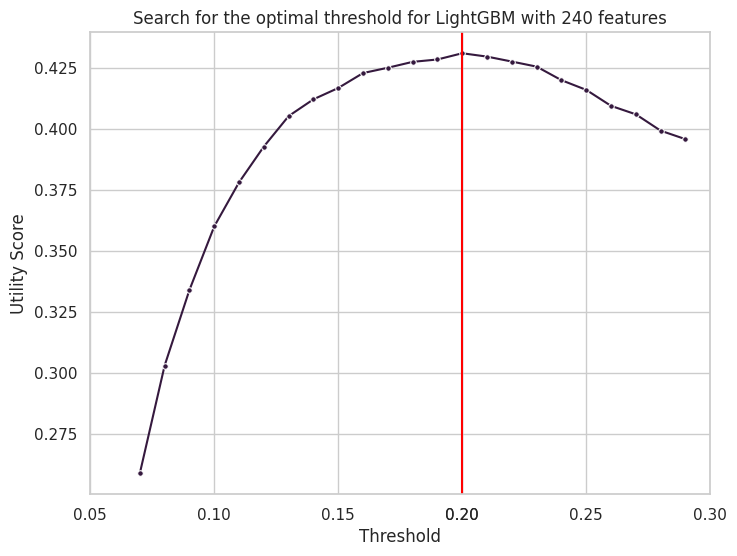

In [55]:
search_thr_graphic(hist, "LightGBM with 240 features", best_t)

In [46]:
importance = model.feature_importance(importance_type='gain')

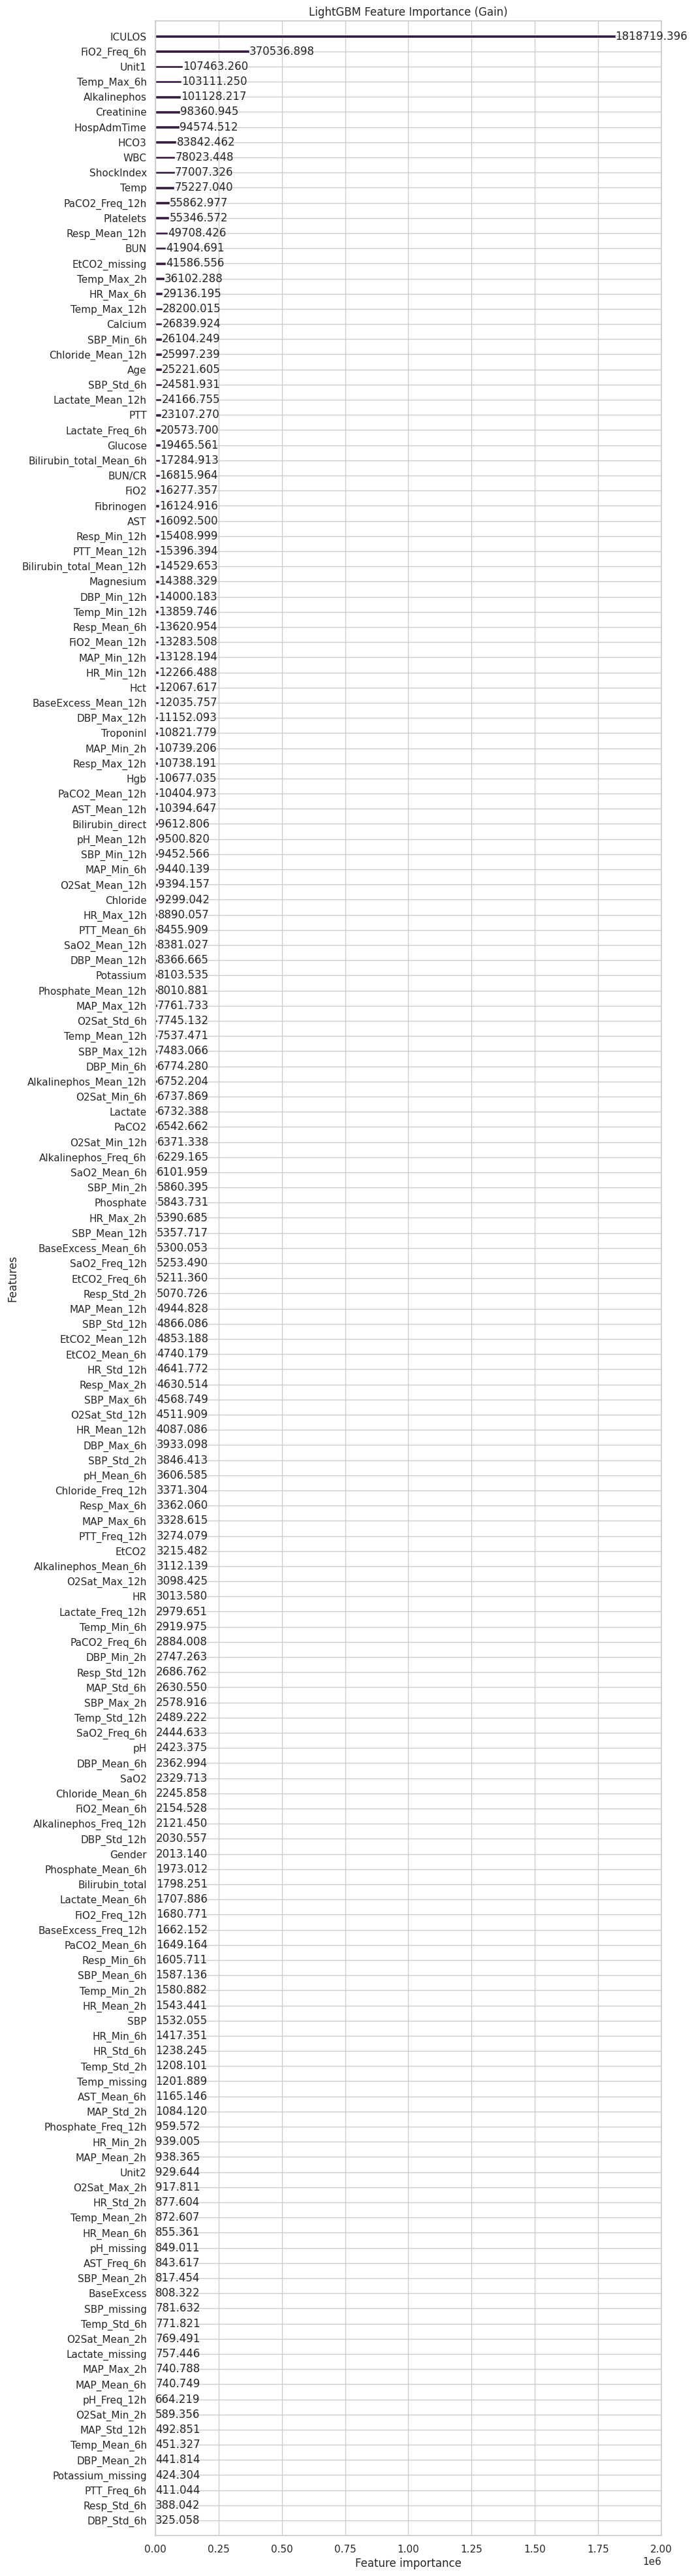

In [47]:
lgb.plot_importance(model, importance_type="gain", figsize=(10,50), title="LightGBM Feature Importance (Gain)")
plt.show()

In [64]:
feature_imp = pd.DataFrame({
    'Gain': model.feature_importance(importance_type='gain'),
    'Feature': df_columns
})

In [49]:
pd.set_option('display.max_rows', 300)

In [65]:
feature_imp = feature_imp.sort_values(by='Gain', ascending=False).reset_index(drop=True)

In [66]:
feature_imp

,Gain,Feature
0,1.818719e+06,ICULOS
1,3.705369e+05,FiO2_Freq_6h
2,1.074633e+05,Unit1
3,1.031112e+05,Temp_Max_6h
4,1.011282e+05,Alkalinephos
5,9.836094e+04,Creatinine
6,9.457451e+04,HospAdmTime
7,8.384246e+04,HCO3
8,7.802345e+04,WBC
9,7.700733e+04,ShockIndex


In [67]:
feature_imp.to_csv("importance_lgbm.csv")

# Feature selection techniques

## Cumulative gain 99%

In [25]:
feature_imp=pd.read_csv('/kaggle/input/datasets/annarechkalova/importance-lgbm/importance_lgbm (2).csv')

In [26]:
feature_imp = feature_imp.sort_values(by='Gain', ascending=False).reset_index(drop=True)

In [27]:
feature_imp

,Unnamed: 0,Gain,Feature
0,0,1.818719e+06,ICULOS
1,1,3.705369e+05,FiO2_Freq_6h
2,2,1.074633e+05,Unit1
3,3,1.031112e+05,Temp_Max_6h
4,4,1.011282e+05,Alkalinephos
...,...,...,...
235,235,0.000000e+00,Resp_Mean_2h
236,236,0.000000e+00,Resp_Min_2h
237,237,0.000000e+00,Resp_Max_3h
238,238,0.000000e+00,Resp_Min_3h


In [27]:
feature_imp['Cumulative_Gain'] = feature_imp['Gain'].cumsum() / feature_imp['Gain'].sum()
top_features = feature_imp[feature_imp['Cumulative_Gain'] <= 0.99]
print(f"Num of features: {len(top_features)}")
selected_features = top_features['Feature'].tolist()

Num of features: 122


In [29]:
selected_features

['ICULOS',
 'FiO2_Freq_6h',
 'Unit1',
 'Temp_Max_6h',
 'Alkalinephos',
 'Creatinine',
 'HospAdmTime',
 'HCO3',
 'WBC',
 'ShockIndex',
 'Temp',
 'PaCO2_Freq_12h',
 'Platelets',
 'Resp_Mean_12h',
 'BUN',
 'EtCO2_missing',
 'Temp_Max_2h',
 'HR_Max_6h',
 'Temp_Max_12h',
 'Calcium',
 'SBP_Min_6h',
 'Chloride_Mean_12h',
 'Age',
 'SBP_Std_6h',
 'Lactate_Mean_12h',
 'PTT',
 'Lactate_Freq_6h',
 'Glucose',
 'Bilirubin_total_Mean_6h',
 'BUN/CR',
 'FiO2',
 'Fibrinogen',
 'AST',
 'Resp_Min_12h',
 'PTT_Mean_12h',
 'Bilirubin_total_Mean_12h',
 'Magnesium',
 'DBP_Min_12h',
 'Temp_Min_12h',
 'Resp_Mean_6h',
 'FiO2_Mean_12h',
 'MAP_Min_12h',
 'HR_Min_12h',
 'Hct',
 'BaseExcess_Mean_12h',
 'DBP_Max_12h',
 'TroponinI',
 'MAP_Min_2h',
 'Resp_Max_12h',
 'Hgb',
 'PaCO2_Mean_12h',
 'AST_Mean_12h',
 'Bilirubin_direct',
 'pH_Mean_12h',
 'SBP_Min_12h',
 'MAP_Min_6h',
 'O2Sat_Mean_12h',
 'Chloride',
 'HR_Max_12h',
 'PTT_Mean_6h',
 'SaO2_Mean_12h',
 'DBP_Mean_12h',
 'Potassium',
 'Phosphate_Mean_12h',
 'MAP_Max_12

In [28]:
X_train_new = train_df[selected_features]
y_train_new = train_df['SepsisLabel']

X_val_new = val_df[selected_features]
y_val_new = val_df['SepsisLabel']

In [32]:
train_data_new = lgb.Dataset(X_train_new, label=y_train_new)
valid_data_new = lgb.Dataset(X_val_new, label=y_val_new, reference=train_data_new)

In [72]:
model_after_selection = lgb.train(
    baseline_params, 
    train_data_new, 
    valid_sets=[valid_data_new], 
    num_boost_round=300,
    feval=auprc_metric,
    callbacks=[
        lgb.log_evaluation(period=10),
        lgb.early_stopping(stopping_rounds=30, first_metric_only=True)
    ]
)

Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.106975
[20]	valid_0's auprc: 0.112892
[30]	valid_0's auprc: 0.115642
[40]	valid_0's auprc: 0.118081
[50]	valid_0's auprc: 0.122816
[60]	valid_0's auprc: 0.120583
[70]	valid_0's auprc: 0.119938
[80]	valid_0's auprc: 0.121293
Early stopping, best iteration is:
[51]	valid_0's auprc: 0.123073
Evaluated only: auprc


In [73]:
best_t_after_selection, best_u_after_selection, hist_after_selection = search_best_threshold(X_val_new, y_val_new, val_df, model_after_selection)
print(f"Best threshold = {best_t_after_selection:.3f}")
print(f"Best utility = {best_u_after_selection:.4f}")

Threshold=0.070 | Utility=0.2591 | AUPRC=0.1231
Threshold=0.080 | Utility=0.3053 | AUPRC=0.1231
Threshold=0.090 | Utility=0.3402 | AUPRC=0.1231
Threshold=0.100 | Utility=0.3632 | AUPRC=0.1231
Threshold=0.110 | Utility=0.3792 | AUPRC=0.1231
Threshold=0.120 | Utility=0.3892 | AUPRC=0.1231
Threshold=0.130 | Utility=0.4023 | AUPRC=0.1231
Threshold=0.140 | Utility=0.4120 | AUPRC=0.1231
Threshold=0.150 | Utility=0.4172 | AUPRC=0.1231
Threshold=0.160 | Utility=0.4202 | AUPRC=0.1231
Threshold=0.170 | Utility=0.4259 | AUPRC=0.1231
Threshold=0.180 | Utility=0.4295 | AUPRC=0.1231
Threshold=0.190 | Utility=0.4319 | AUPRC=0.1231
Threshold=0.200 | Utility=0.4323 | AUPRC=0.1231
Threshold=0.210 | Utility=0.4318 | AUPRC=0.1231
Threshold=0.220 | Utility=0.4288 | AUPRC=0.1231
Threshold=0.230 | Utility=0.4276 | AUPRC=0.1231
Threshold=0.240 | Utility=0.4234 | AUPRC=0.1231
Threshold=0.250 | Utility=0.4200 | AUPRC=0.1231
Threshold=0.260 | Utility=0.4166 | AUPRC=0.1231
Threshold=0.270 | Utility=0.4122 | AUPRC

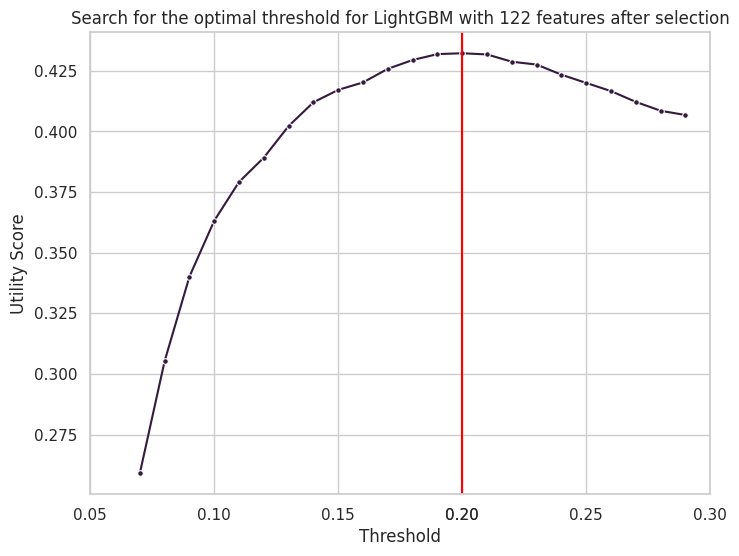

In [74]:
search_thr_graphic(hist_after_selection, "LightGBM with 122 features after selection", best_t_after_selection)

## Cumulative gain 95%

In [75]:
top_features_ninety_five = feature_imp[feature_imp['Cumulative_Gain'] <= 0.95]
print(f"Num of features: {len(top_features_ninety_five)}")
selected_features_ninety_five = top_features_ninety_five['Feature'].tolist()

Num of features: 75


In [76]:
selected_features_ninety_five

['ICULOS',
 'FiO2_Freq_6h',
 'Unit1',
 'Temp_Max_6h',
 'Alkalinephos',
 'Creatinine',
 'HospAdmTime',
 'HCO3',
 'WBC',
 'ShockIndex',
 'Temp',
 'PaCO2_Freq_12h',
 'Platelets',
 'Resp_Mean_12h',
 'BUN',
 'EtCO2_missing',
 'Temp_Max_2h',
 'HR_Max_6h',
 'Temp_Max_12h',
 'Calcium',
 'SBP_Min_6h',
 'Chloride_Mean_12h',
 'Age',
 'SBP_Std_6h',
 'Lactate_Mean_12h',
 'PTT',
 'Lactate_Freq_6h',
 'Glucose',
 'Bilirubin_total_Mean_6h',
 'BUN/CR',
 'FiO2',
 'Fibrinogen',
 'AST',
 'Resp_Min_12h',
 'PTT_Mean_12h',
 'Bilirubin_total_Mean_12h',
 'Magnesium',
 'DBP_Min_12h',
 'Temp_Min_12h',
 'Resp_Mean_6h',
 'FiO2_Mean_12h',
 'MAP_Min_12h',
 'HR_Min_12h',
 'Hct',
 'BaseExcess_Mean_12h',
 'DBP_Max_12h',
 'TroponinI',
 'MAP_Min_2h',
 'Resp_Max_12h',
 'Hgb',
 'PaCO2_Mean_12h',
 'AST_Mean_12h',
 'Bilirubin_direct',
 'pH_Mean_12h',
 'SBP_Min_12h',
 'MAP_Min_6h',
 'O2Sat_Mean_12h',
 'Chloride',
 'HR_Max_12h',
 'PTT_Mean_6h',
 'SaO2_Mean_12h',
 'DBP_Mean_12h',
 'Potassium',
 'Phosphate_Mean_12h',
 'MAP_Max_12

In [77]:
X_train_new_ninety_five = train_df[selected_features_ninety_five]
y_train_new_ninety_five = train_df['SepsisLabel']

X_val_new_ninety_five = val_df[selected_features_ninety_five]
y_val_new_ninety_five = val_df['SepsisLabel']

In [78]:
train_data_new_ninety_five = lgb.Dataset(X_train_new_ninety_five, label=y_train_new_ninety_five)
valid_data_new_ninety_five = lgb.Dataset(X_val_new_ninety_five, label=y_val_new_ninety_five, reference=train_data_new_ninety_five)

In [79]:
model_after_selection_ninety_five = lgb.train(
    baseline_params, 
    train_data_new_ninety_five, 
    valid_sets=[valid_data_new_ninety_five], 
    num_boost_round=300,
    feval=auprc_metric,
    callbacks=[
        lgb.log_evaluation(period=10),
        lgb.early_stopping(stopping_rounds=30, first_metric_only=True)
    ]
)

Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.108578
[20]	valid_0's auprc: 0.114722
[30]	valid_0's auprc: 0.116743
[40]	valid_0's auprc: 0.117605
[50]	valid_0's auprc: 0.116903
[60]	valid_0's auprc: 0.116891
Early stopping, best iteration is:
[37]	valid_0's auprc: 0.118298
Evaluated only: auprc


In [80]:
best_t_after_selection_ninety_five, best_u_after_selection_ninety_five, hist_after_selection_ninety_five = search_best_threshold(X_val_new_ninety_five, y_val_new_ninety_five, val_df, model_after_selection_ninety_five)
print(f"Best threshold = {best_t_after_selection_ninety_five:.3f}")
print(f"Best utility = {best_u_after_selection_ninety_five:.4f}")

Threshold=0.070 | Utility=0.2464 | AUPRC=0.1183
Threshold=0.080 | Utility=0.2960 | AUPRC=0.1183
Threshold=0.090 | Utility=0.3331 | AUPRC=0.1183
Threshold=0.100 | Utility=0.3552 | AUPRC=0.1183
Threshold=0.110 | Utility=0.3741 | AUPRC=0.1183
Threshold=0.120 | Utility=0.3892 | AUPRC=0.1183
Threshold=0.130 | Utility=0.4010 | AUPRC=0.1183
Threshold=0.140 | Utility=0.4096 | AUPRC=0.1183
Threshold=0.150 | Utility=0.4178 | AUPRC=0.1183
Threshold=0.160 | Utility=0.4204 | AUPRC=0.1183
Threshold=0.170 | Utility=0.4199 | AUPRC=0.1183
Threshold=0.180 | Utility=0.4239 | AUPRC=0.1183
Threshold=0.190 | Utility=0.4273 | AUPRC=0.1183
Threshold=0.200 | Utility=0.4255 | AUPRC=0.1183
Threshold=0.210 | Utility=0.4239 | AUPRC=0.1183
Threshold=0.220 | Utility=0.4215 | AUPRC=0.1183
Threshold=0.230 | Utility=0.4182 | AUPRC=0.1183
Threshold=0.240 | Utility=0.4181 | AUPRC=0.1183
Threshold=0.250 | Utility=0.4177 | AUPRC=0.1183
Threshold=0.260 | Utility=0.4154 | AUPRC=0.1183
Threshold=0.270 | Utility=0.4143 | AUPRC

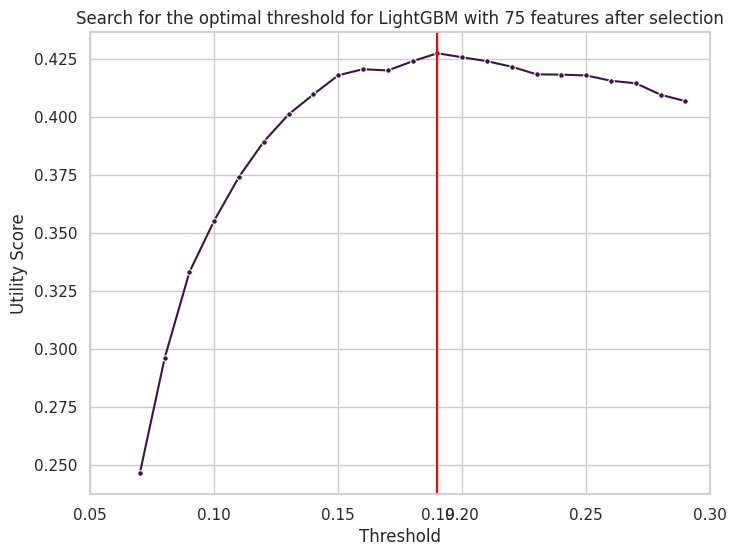

In [82]:
search_thr_graphic(hist_after_selection_ninety_five, "LightGBM with 75 features after selection", best_t_after_selection_ninety_five)

## Mean on all features

In [83]:
mean_gain = feature_imp['Gain'].mean()
print(f"mean gain: {mean_gain:.2f}")
top_features_mean = feature_imp[feature_imp['Gain'] > mean_gain].sort_values(by="Gain", ascending=False)
print(f"num of features: {len(top_features_mean)}")
selected_features_mean = top_features_mean['Feature'].tolist()

mean gain: 17843.41
num of features: 28


In [84]:
selected_features_mean

['ICULOS',
 'FiO2_Freq_6h',
 'Unit1',
 'Temp_Max_6h',
 'Alkalinephos',
 'Creatinine',
 'HospAdmTime',
 'HCO3',
 'WBC',
 'ShockIndex',
 'Temp',
 'PaCO2_Freq_12h',
 'Platelets',
 'Resp_Mean_12h',
 'BUN',
 'EtCO2_missing',
 'Temp_Max_2h',
 'HR_Max_6h',
 'Temp_Max_12h',
 'Calcium',
 'SBP_Min_6h',
 'Chloride_Mean_12h',
 'Age',
 'SBP_Std_6h',
 'Lactate_Mean_12h',
 'PTT',
 'Lactate_Freq_6h',
 'Glucose']

In [85]:
X_train_mean_selection = train_df[selected_features_mean]
y_train_mean_selection = train_df['SepsisLabel']

X_val_mean_selection = val_df[selected_features_mean]
y_val_mean_selection = val_df['SepsisLabel']

In [86]:
train_data_mean = lgb.Dataset(X_train_mean_selection, label=y_train_mean_selection)
valid_data_mean = lgb.Dataset(X_val_mean_selection, label=y_val_mean_selection, reference=train_data_mean)

In [87]:
model_mean = lgb.train(
    baseline_params, 
    train_data_mean, 
    valid_sets=[valid_data_mean], 
    num_boost_round=300,
    feval=auprc_metric,
    callbacks=[
        lgb.log_evaluation(period=10),
        lgb.early_stopping(stopping_rounds=30, first_metric_only=True)
    ]
)

Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.106023
[20]	valid_0's auprc: 0.108588
[30]	valid_0's auprc: 0.111599
[40]	valid_0's auprc: 0.109694
[50]	valid_0's auprc: 0.10943
[60]	valid_0's auprc: 0.109201
Early stopping, best iteration is:
[34]	valid_0's auprc: 0.112048
Evaluated only: auprc


In [88]:
best_t_mean, best_u_mean, hist_mean = search_best_threshold(X_val_mean_selection, y_val_mean_selection, val_df, model_mean)
print(f"Best threshold = {best_t_mean:.3f}")
print(f"Best utility = {best_u_mean:.4f}")

Threshold=0.070 | Utility=0.2426 | AUPRC=0.1120
Threshold=0.080 | Utility=0.2799 | AUPRC=0.1120
Threshold=0.090 | Utility=0.3119 | AUPRC=0.1120
Threshold=0.100 | Utility=0.3378 | AUPRC=0.1120
Threshold=0.110 | Utility=0.3582 | AUPRC=0.1120
Threshold=0.120 | Utility=0.3733 | AUPRC=0.1120
Threshold=0.130 | Utility=0.3881 | AUPRC=0.1120
Threshold=0.140 | Utility=0.3983 | AUPRC=0.1120
Threshold=0.150 | Utility=0.4055 | AUPRC=0.1120
Threshold=0.160 | Utility=0.4136 | AUPRC=0.1120
Threshold=0.170 | Utility=0.4170 | AUPRC=0.1120
Threshold=0.180 | Utility=0.4230 | AUPRC=0.1120
Threshold=0.190 | Utility=0.4218 | AUPRC=0.1120
Threshold=0.200 | Utility=0.4186 | AUPRC=0.1120
Threshold=0.210 | Utility=0.4169 | AUPRC=0.1120
Threshold=0.220 | Utility=0.4161 | AUPRC=0.1120
Threshold=0.230 | Utility=0.4131 | AUPRC=0.1120
Threshold=0.240 | Utility=0.4113 | AUPRC=0.1120
Threshold=0.250 | Utility=0.4082 | AUPRC=0.1120
Threshold=0.260 | Utility=0.4072 | AUPRC=0.1120
Threshold=0.270 | Utility=0.4048 | AUPRC

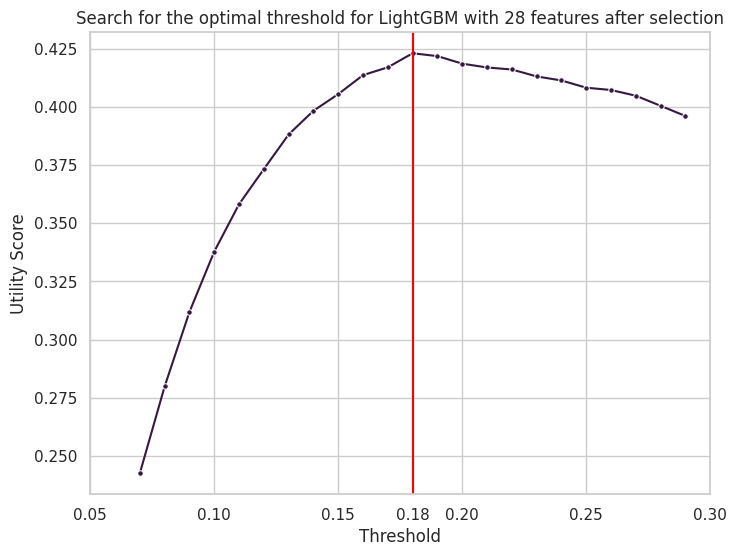

In [90]:
search_thr_graphic(hist_mean, "LightGBM with 28 features after selection", best_t_mean)

# Model selection

## Random search

In [34]:
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import ParameterSampler
from scipy.stats import uniform, randint, loguniform
from sklearn.metrics import average_precision_score

In [35]:
def get_param_grid():
    return {
        'max_bin': randint(64, 513),
        'lambda_l1': loguniform(1e-8, 10.0),
        'lambda_l2': loguniform(1e-8, 10.0),
        'max_depth': randint(3, 16),
        'feature_fraction': uniform(0.4, 0.6),  # 0.4 + 0.6 = 1.0
        'min_data_in_leaf': randint(20, 151),
        'learning_rate': loguniform(0.005, 0.1),
        'scale_pos_weight': uniform(10, 5),     # 10 + 5 = 15
        'min_gain_to_split': uniform(0.0, 1.0),
        'top_rate': uniform(0.1, 0.2),          # 0.1 + 0.2 = 0.3
        'other_rate': uniform(0.05, 0.15)       # 0.05 + 0.15 = 0.2
    }

In [36]:
def train_model(params, train_set, val_set):
    lgb_params = {
        'objective': 'binary',
        'metric': 'None',
        'boosting': 'gbdt',
        'data_sample_strategy': 'goss',
        'verbose': -1,
        **params
    }
    lgb_params['num_leaves'] = int(0.7 * (2 ** lgb_params['max_depth']))

    model = lgb.train(
        lgb_params,
        train_set,
        valid_sets=[val_set],
        num_boost_round=1000,
        feval=auprc_metric,
        callbacks=[
            lgb.log_evaluation(period=0),
            lgb.early_stopping(stopping_rounds=30, first_metric_only=True)
        ]
    )
    return model, lgb_params

In [39]:
def run_random_search(X_train, y_train, X_val, y_val, n_iter):
    param_grid = get_param_grid()
    param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))
    best_score = -1
    best_params = None

    for i, params in enumerate(param_list):
        train_ds = lgb.Dataset(X_train, label=y_train, params={'max_bin': params['max_bin']})
        val_ds = lgb.Dataset(X_val, label=y_val, reference=train_ds, params={'max_bin': params['max_bin']})
        
        model, lgb_params = train_model(params, train_ds, val_ds)
    
        preds = model.predict(X_val)
        average_precision = average_precision_score(y_val, preds)
        
        if average_precision > best_score:
            best_score = average_precision
            best_params = params
            
        print(f"Iteration {i+1}/{n_iter} | AUPRC: {average_precision:.4f} | Best AUPRC: {best_score:.4f} \nParams: {lgb_params}\n")

    return best_params, best_score

In [42]:
best_p, best_s = run_random_search(X_train_new, y_train_new, X_val_new, y_val_new, n_iter=70)

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[129]	valid_0's auprc: 0.0982932
Evaluated only: auprc
Iteration 1/70 | AUPRC: 0.0983 | Best AUPRC: 0.0983 
Params: {'objective': 'binary', 'metric': 'None', 'boosting': 'gbdt', 'data_sample_strategy': 'goss', 'verbose': -1, 'feature_fraction': np.float64(0.6247240713084175), 'lambda_l1': np.float64(3.6010467344475403), 'lambda_l2': np.float64(0.038720902953704193), 'learning_rate': np.float64(0.030049873591901578), 'max_bin': 166, 'max_depth': 12, 'min_data_in_leaf': 94, 'min_gain_to_split': np.float64(0.45924889196586716), 'other_rate': np.float64(0.10005629167085328), 'scale_pos_weight': np.float64(10.714334089609704), 'top_rate': np.float64(0.23017769458977058), 'num_leaves': 2867}

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[8]	valid_0's auprc: 0.115189
Evaluated only: auprc
Iteration 2/70 | AUPRC: 0.1152 | Best AUPRC: 0.1152 
Params:

In [44]:
print(best_p)

{'feature_fraction': np.float64(0.8830268005116171), 'lambda_l1': np.float64(1.3438770213234963), 'lambda_l2': np.float64(0.0035923067048147517), 'learning_rate': np.float64(0.0943151412096879), 'max_bin': 369, 'max_depth': 4, 'min_data_in_leaf': 101, 'min_gain_to_split': np.float64(0.3922440450997323), 'other_rate': np.float64(0.11562123830355936), 'scale_pos_weight': np.float64(14.520793472468743), 'top_rate': np.float64(0.16965109340466006)}


In [45]:
print(best_s)

0.13859516750314277


## Optuna

In [45]:
def objective(trial):
    num_boost_round = 1000
    # boosting = trial.suggest_categorical('boosting_type', ['gbdt', 'dart'])
    boosting = 'gbdt'
    max_bin = trial.suggest_int('max_bin', 64, 512)

    param = {
        'objective': 'binary',
        'metric': 'None',
        'boosting': boosting,
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 10, 15),
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0),
        'verbose': -1
    }

    param['num_leaves'] = int(0.7 * (2 ** param['max_depth']))

    # if boosting == 'dart':
    #     param['data_sample_strategy'] = 'bagging'
    #     param['drop_rate'] = trial.suggest_float('drop_rate', 0.05, 0.2)
    #     param['bagging_fraction'] = trial.suggest_float('bagging_fraction', 0.5, 1.0)
    #     param['bagging_freq'] = trial.suggest_int('bagging_freq', 1, 10)
    # elif boosting == 'gbdt':
    # strategy = trial.suggest_categorical('data_sample_strategy', ['goss'])
    # param['data_sample_strategy'] = strategy
    param['data_sample_strategy'] = 'goss'
    param['top_rate'] = trial.suggest_float('top_rate', 0.1, 0.3)
    param['other_rate'] = trial.suggest_float('other_rate', 0.05, 0.2)

    train_ds = lgb.Dataset(X_train_new, label=y_train_new, params={'max_bin': max_bin})
    val_ds = lgb.Dataset(X_val_new, label=y_val_new, reference=train_ds, params={'max_bin': max_bin})
    model = lgb.train(param, 
                      train_ds, 
                      valid_sets=[val_ds], 
                      num_boost_round=num_boost_round, 
                      feval=auprc_metric,
                      callbacks=[
        lgb.log_evaluation(period=10),
        lgb.early_stopping(stopping_rounds=30, first_metric_only=True)
    ])

    preds = model.predict(X_val_new)
    average_precision = average_precision_score(y_val_new, preds)

    print(f"Trial {trial.number}: AUPRC = {average_precision:.4f}")
    return average_precision

In [33]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2026-02-23 12:25:11,057] A new study created in memory with name: no-name-61fe9022-4eba-4233-8274-69bbc494c564


Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.0930118
[20]	valid_0's auprc: 0.095869
[30]	valid_0's auprc: 0.0968877
[40]	valid_0's auprc: 0.097434
[50]	valid_0's auprc: 0.0983153
[60]	valid_0's auprc: 0.0985262
[70]	valid_0's auprc: 0.0987967
[80]	valid_0's auprc: 0.0986368
[90]	valid_0's auprc: 0.0984228
Early stopping, best iteration is:
[62]	valid_0's auprc: 0.0989211
Evaluated only: auprc


[I 2026-02-23 12:26:19,001] Trial 0 finished with value: 0.09892106242148621 and parameters: {'max_bin': 237, 'lambda_l1': 0.00034580948485191934, 'lambda_l2': 2.179428067264312e-06, 'max_depth': 12, 'feature_fraction': 0.6779640020930917, 'min_data_in_leaf': 48, 'learning_rate': 0.011672357633515438, 'scale_pos_weight': 14.387208176700534, 'min_gain_to_split': 0.6037691742627581, 'top_rate': 0.11716737887226097, 'other_rate': 0.17492028215339767}. Best is trial 0 with value: 0.09892106242148621.


Trial 0: AUPRC = 0.0989
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.0967351
[20]	valid_0's auprc: 0.101417
[30]	valid_0's auprc: 0.102573
[40]	valid_0's auprc: 0.105139
[50]	valid_0's auprc: 0.106454
[60]	valid_0's auprc: 0.107176
[70]	valid_0's auprc: 0.106709
[80]	valid_0's auprc: 0.107114
[90]	valid_0's auprc: 0.10604
Early stopping, best iteration is:
[61]	valid_0's auprc: 0.107896
Evaluated only: auprc


[I 2026-02-23 12:26:51,923] Trial 1 finished with value: 0.10789629475938109 and parameters: {'max_bin': 141, 'lambda_l1': 7.244853253751618e-05, 'lambda_l2': 0.2329184282249273, 'max_depth': 9, 'feature_fraction': 0.7315973131302851, 'min_data_in_leaf': 86, 'learning_rate': 0.05577410264236618, 'scale_pos_weight': 14.294146337125817, 'min_gain_to_split': 0.5225883852879826, 'top_rate': 0.20968408145085715, 'other_rate': 0.10418144005299128}. Best is trial 1 with value: 0.10789629475938109.


...

Trial 47: AUPRC = 0.1367
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.112161
[20]	valid_0's auprc: 0.125593
[30]	valid_0's auprc: 0.131617
[40]	valid_0's auprc: 0.135243
[50]	valid_0's auprc: 0.134866
[60]	valid_0's auprc: 0.135823
[70]	valid_0's auprc: 0.136592
[80]	valid_0's auprc: 0.136745
[90]	valid_0's auprc: 0.136655
Early stopping, best iteration is:
[68]	valid_0's auprc: 0.137314
Evaluated only: auprc


[I 2026-02-23 12:59:41,987] Trial 48 finished with value: 0.13731411685066808 and parameters: {'max_bin': 319, 'lambda_l1': 2.8473218056162096e-08, 'lambda_l2': 0.004308119676716806, 'max_depth': 4, 'feature_fraction': 0.7858936706005131, 'min_data_in_leaf': 123, 'learning_rate': 0.08386254005902477, 'scale_pos_weight': 12.585433900703125, 'min_gain_to_split': 0.231839058645553, 'top_rate': 0.1699610079422932, 'other_rate': 0.11464231245669768}. Best is trial 46 with value: 0.1402925318400648.


Trial 48: AUPRC = 0.1373
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.0990195
[20]	valid_0's auprc: 0.103537
[30]	valid_0's auprc: 0.107333
[40]	valid_0's auprc: 0.108836
[50]	valid_0's auprc: 0.108824
[60]	valid_0's auprc: 0.108997
[70]	valid_0's auprc: 0.109035
Early stopping, best iteration is:
[41]	valid_0's auprc: 0.109183
Evaluated only: auprc


[I 2026-02-23 13:00:04,311] Trial 49 finished with value: 0.10918336690538716 and parameters: {'max_bin': 434, 'lambda_l1': 4.831106836697818e-08, 'lambda_l2': 0.04735754154777104, 'max_depth': 6, 'feature_fraction': 0.7858141829852462, 'min_data_in_leaf': 116, 'learning_rate': 0.08393250805297316, 'scale_pos_weight': 13.688463046392364, 'min_gain_to_split': 0.22277106832207522, 'top_rate': 0.17177929977011827, 'other_rate': 0.14906721188064836}. Best is trial 46 with value: 0.1402925318400648.


Trial 49: AUPRC = 0.1092


In [46]:
study.optimize(objective, n_trials=20)

Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.104091
[20]	valid_0's auprc: 0.110406
[30]	valid_0's auprc: 0.113319
[40]	valid_0's auprc: 0.115787
[50]	valid_0's auprc: 0.118117
[60]	valid_0's auprc: 0.120379
[70]	valid_0's auprc: 0.122099
[80]	valid_0's auprc: 0.123835
[90]	valid_0's auprc: 0.124949
[100]	valid_0's auprc: 0.126459
[110]	valid_0's auprc: 0.127685
[120]	valid_0's auprc: 0.127975
[130]	valid_0's auprc: 0.128725
[140]	valid_0's auprc: 0.128649
[150]	valid_0's auprc: 0.129144
[160]	valid_0's auprc: 0.12929
[170]	valid_0's auprc: 0.129409
[180]	valid_0's auprc: 0.129883
[190]	valid_0's auprc: 0.129833
[200]	valid_0's auprc: 0.130005
[210]	valid_0's auprc: 0.13
[220]	valid_0's auprc: 0.1299
Early stopping, best iteration is:
[192]	valid_0's auprc: 0.130245
Evaluated only: auprc


[I 2026-02-23 13:07:08,704] Trial 50 finished with value: 0.1302448893595133 and parameters: {'max_bin': 401, 'lambda_l1': 3.001606163383396e-08, 'lambda_l2': 0.28745759520647163, 'max_depth': 3, 'feature_fraction': 0.7637574024913952, 'min_data_in_leaf': 125, 'learning_rate': 0.0563342207269038, 'scale_pos_weight': 12.708075168896887, 'min_gain_to_split': 0.07355038341332981, 'top_rate': 0.18804035422254697, 'other_rate': 0.12951270586792943}. Best is trial 46 with value: 0.1402925318400648.


Trial 50: AUPRC = 0.1302
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.1036
[20]	valid_0's auprc: 0.110326
[30]	valid_0's auprc: 0.11402
[40]	valid_0's auprc: 0.118146
[50]	valid_0's auprc: 0.121638
[60]	valid_0's auprc: 0.12404
[70]	valid_0's auprc: 0.124237
[80]	valid_0's auprc: 0.124901
[90]	valid_0's auprc: 0.124338
[100]	valid_0's auprc: 0.124275
Early stopping, best iteration is:
[75]	valid_0's auprc: 0.12491
Evaluated only: auprc


[I 2026-02-23 13:07:30,438] Trial 51 finished with value: 0.12491048123719108 and parameters: {'max_bin': 253, 'lambda_l1': 1.57104868585369e-07, 'lambda_l2': 2.268301137436788, 'max_depth': 3, 'feature_fraction': 0.8260268772765228, 'min_data_in_leaf': 136, 'learning_rate': 0.09205015142476042, 'scale_pos_weight': 11.882128221149935, 'min_gain_to_split': 0.24097272511417916, 'top_rate': 0.1671764653961945, 'other_rate': 0.11415524446279654}. Best is trial 46 with value: 0.1402925318400648.


Trial 51: AUPRC = 0.1249
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.10271
[20]	valid_0's auprc: 0.107888
[30]	valid_0's auprc: 0.114314
[40]	valid_0's auprc: 0.116849
[50]	valid_0's auprc: 0.119473
[60]	valid_0's auprc: 0.122012
[70]	valid_0's auprc: 0.123632
[80]	valid_0's auprc: 0.125157
[90]	valid_0's auprc: 0.126284
[100]	valid_0's auprc: 0.127534
[110]	valid_0's auprc: 0.128415
[120]	valid_0's auprc: 0.128589
[130]	valid_0's auprc: 0.129511
[140]	valid_0's auprc: 0.130362
[150]	valid_0's auprc: 0.130462
[160]	valid_0's auprc: 0.130893
[170]	valid_0's auprc: 0.131066
[180]	valid_0's auprc: 0.130546
[190]	valid_0's auprc: 0.130815
Early stopping, best iteration is:
[166]	valid_0's auprc: 0.131123
Evaluated only: auprc


...

Trial 67: AUPRC = 0.1364
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.105459
[20]	valid_0's auprc: 0.111013
[30]	valid_0's auprc: 0.115503
[40]	valid_0's auprc: 0.118989
[50]	valid_0's auprc: 0.118834
[60]	valid_0's auprc: 0.119019
[70]	valid_0's auprc: 0.12006
[80]	valid_0's auprc: 0.119658
[90]	valid_0's auprc: 0.11906
[100]	valid_0's auprc: 0.119018
Early stopping, best iteration is:
[78]	valid_0's auprc: 0.12032
Evaluated only: auprc


[I 2026-02-23 13:16:47,721] Trial 68 finished with value: 0.12031976983687952 and parameters: {'max_bin': 260, 'lambda_l1': 7.204047429500231e-07, 'lambda_l2': 0.0001118408603875006, 'max_depth': 6, 'feature_fraction': 0.7359887252287801, 'min_data_in_leaf': 90, 'learning_rate': 0.0792490966858529, 'scale_pos_weight': 12.2186855994265, 'min_gain_to_split': 0.76859164188111, 'top_rate': 0.18832138495247186, 'other_rate': 0.12658908067757416}. Best is trial 57 with value: 0.14387713680462197.


Trial 68: AUPRC = 0.1203
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.105147
[20]	valid_0's auprc: 0.11027
[30]	valid_0's auprc: 0.115803
[40]	valid_0's auprc: 0.118822
[50]	valid_0's auprc: 0.118983
[60]	valid_0's auprc: 0.120259
[70]	valid_0's auprc: 0.12137
[80]	valid_0's auprc: 0.123138
[90]	valid_0's auprc: 0.125778
[100]	valid_0's auprc: 0.126451
[110]	valid_0's auprc: 0.128288
[120]	valid_0's auprc: 0.128082
[130]	valid_0's auprc: 0.129087
[140]	valid_0's auprc: 0.129623
[150]	valid_0's auprc: 0.129039
[160]	valid_0's auprc: 0.128362
Early stopping, best iteration is:
[137]	valid_0's auprc: 0.130195
Evaluated only: auprc


[I 2026-02-23 13:17:18,477] Trial 69 finished with value: 0.13019468730864167 and parameters: {'max_bin': 412, 'lambda_l1': 0.012340570560976087, 'lambda_l2': 4.497486074305303e-05, 'max_depth': 4, 'feature_fraction': 0.45713856300299044, 'min_data_in_leaf': 50, 'learning_rate': 0.09166547952981449, 'scale_pos_weight': 12.875021698527332, 'min_gain_to_split': 0.21282591652976568, 'top_rate': 0.17787497643890893, 'other_rate': 0.13291215292612377}. Best is trial 57 with value: 0.14387713680462197.


Trial 69: AUPRC = 0.1302


In [47]:
import joblib
joblib.dump(study, 'study.pkl')

['study.pkl']

In [48]:
df_results = study.trials_dataframe()
df_results

,number,value,datetime_start,datetime_complete,duration,params_feature_fraction,params_lambda_l1,params_lambda_l2,params_learning_rate,params_max_bin,params_max_depth,params_min_data_in_leaf,params_min_gain_to_split,params_other_rate,params_scale_pos_weight,params_top_rate,state
0,0,0.098921,2026-02-23 12:25:11.060375,2026-02-23 12:26:19.001268,0 days 00:01:07.940893,0.677964,3.458095e-04,0.000002,0.011672,237,12,48,0.603769,0.174920,14.387208,0.117167,COMPLETE
1,1,0.107896,2026-02-23 12:26:19.002485,2026-02-23 12:26:51.922830,0 days 00:00:32.920345,0.731597,7.244853e-05,0.232918,0.055774,141,9,86,0.522588,0.104181,14.294146,0.209684,COMPLETE
2,2,0.128129,2026-02-23 12:26:51.924187,2026-02-23 12:27:11.465830,0 days 00:00:19.541643,0.763265,1.119403e-05,0.000001,0.008524,154,7,107,0.583762,0.102184,14.283911,0.187404,COMPLETE
3,3,0.138601,2026-02-23 12:27:11.467231,2026-02-23 12:27:30.696593,0 days 00:00:19.229362,0.654630,5.512989e-08,2.816042,0.077321,188,5,76,0.597141,0.064262,11.898972,0.172956,COMPLETE
4,4,0.122419,2026-02-23 12:27:30.697848,2026-02-23 12:28:34.209370,0 days 00:01:03.511522,0.846370,1.248738e-07,0.000032,0.015378,110,8,143,0.868806,0.157566,14.637051,0.290907,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,65,0.132441,2026-02-23 13:14:31.362481,2026-02-23 13:15:15.394480,0 days 00:00:44.031999,0.555360,1.386139e-08,0.115597,0.060374,379,3,61,0.533957,0.051035,12.103709,0.172096,COMPLETE
66,66,0.133672,2026-02-23 13:15:15.395718,2026-02-23 13:15:43.747123,0 days 00:00:28.351405,0.529541,2.760104e-07,0.000335,0.046005,437,5,103,0.608586,0.080975,11.745436,0.155503,COMPLETE
67,67,0.136402,2026-02-23 13:15:43.748416,2026-02-23 13:16:20.028504,0 days 00:00:36.280088,0.601111,1.020384e-08,4.205222,0.037090,454,4,125,0.444441,0.071401,12.557334,0.137476,COMPLETE
68,68,0.120320,2026-02-23 13:16:20.029586,2026-02-23 13:16:47.721031,0 days 00:00:27.691445,0.735989,7.204047e-07,0.000112,0.079249,260,6,90,0.768592,0.126589,12.218686,0.188321,COMPLETE


In [49]:
optuna.visualization.plot_optimization_history(study)

In [50]:
optuna.visualization.plot_slice(study)

In [51]:
optuna.visualization.plot_param_importances(
    study,
    evaluator=MeanDecreaseImpurityImportanceEvaluator()
)

In [52]:
params = study.best_params

In [53]:
params

{'max_bin': 512,
 'lambda_l1': 1.2958264081350343e-07,
 'lambda_l2': 6.151037127082509e-05,
 'max_depth': 4,
 'feature_fraction': 0.9522861735245841,
 'min_data_in_leaf': 94,
 'learning_rate': 0.07227593260441952,
 'scale_pos_weight': 11.379394665628105,
 'min_gain_to_split': 0.35449824214080233,
 'top_rate': 0.204634181603536,
 'other_rate': 0.05349474656893903}

In [ ]:
params['objective'] = 'binary'
params['num_leaves'] = 45
params['seed'] = 42

In [ ]:
params

## Final studying with the best params

In [29]:
params = {'max_bin': 512,
 'lambda_l1': 1.2958264081350343e-07,
 'lambda_l2': 6.151037127082509e-05,
 'max_depth': 4,
 'feature_fraction': 0.9522861735245841,
 'min_data_in_leaf': 94,
 'learning_rate': 0.07227593260441952,
 'scale_pos_weight': 11.379394665628105,
 'min_gain_to_split': 0.35449824214080233,
 'top_rate': 0.204634181603536,
 'other_rate': 0.05349474656893903}

In [30]:
params['objective'] = 'binary'
params['num_leaves'] = 45
params['seed'] = 42
params['metric'] = 'None'
params['num_leaves'] = int(0.7 * (2 ** params['max_depth']))

In [31]:
params

{'max_bin': 512,
 'lambda_l1': 1.2958264081350343e-07,
 'lambda_l2': 6.151037127082509e-05,
 'max_depth': 4,
 'feature_fraction': 0.9522861735245841,
 'min_data_in_leaf': 94,
 'learning_rate': 0.07227593260441952,
 'scale_pos_weight': 11.379394665628105,
 'min_gain_to_split': 0.35449824214080233,
 'top_rate': 0.204634181603536,
 'other_rate': 0.05349474656893903,
 'objective': 'binary',
 'num_leaves': 11,
 'seed': 42,
 'metric': 'None'}

In [32]:
train_ds = lgb.Dataset(X_train_new, label=y_train_new, params={'max_bin': params['max_bin']})
val_ds = lgb.Dataset(X_val_new, label=y_val_new, reference=train_ds, params={'max_bin': params['max_bin']})
model = lgb.train(params, 
                  train_ds, 
                  valid_sets=[val_ds], 
                  num_boost_round=1000, 
                  feval=auprc_metric,
                  callbacks=[
    lgb.log_evaluation(period=10),
    lgb.early_stopping(stopping_rounds=100, first_metric_only=True)
])

preds = model.predict(X_val_new)
average_precision = average_precision_score(y_val_new, preds)

[LightGBM] [Info] Number of positive: 20855, number of negative: 1143678
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.020731 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40761
[LightGBM] [Info] Number of data points in the train set: 1164533, number of used features: 122
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.017908 -> initscore=-4.004411
[LightGBM] [Info] Start training from score -4.004411
Training until validation scores don't improve for 100 rounds
[10]	valid_0's auprc: 0.114541
[20]	valid_0's auprc: 0.119998
[30]	valid_0's auprc: 0.12357
[40]	valid_0's auprc: 0.127914
[50]	valid_0's auprc: 0.13148
[60]	valid_0's auprc: 0.132819
[70]	valid_0's auprc: 0.133783
[80]	valid_0's auprc: 0.13549
[90]	valid_0's auprc: 0.13394
[100]	valid_0's auprc: 0.134184
[110]	valid_0's auprc: 0.135447
[120]	valid_0's auprc: 0.135784
[LightGBM] [Warning] No further splits with positive gain, best gai

In [50]:
best_t_final, best_u_final, hist_final = search_best_threshold(X_val_new, y_val_new, val_df, model)
print(f"Best threshold = {best_t_final:.3f}")
print(f"Best utility = {best_u_final:.4f}")

Threshold=0.070 | Utility=0.2262 | AUPRC=0.1371
Threshold=0.080 | Utility=0.2804 | AUPRC=0.1371
Threshold=0.090 | Utility=0.3261 | AUPRC=0.1371
Threshold=0.100 | Utility=0.3583 | AUPRC=0.1371
Threshold=0.110 | Utility=0.3841 | AUPRC=0.1371
Threshold=0.120 | Utility=0.4026 | AUPRC=0.1371
Threshold=0.130 | Utility=0.4182 | AUPRC=0.1371
Threshold=0.140 | Utility=0.4301 | AUPRC=0.1371
Threshold=0.150 | Utility=0.4393 | AUPRC=0.1371
Threshold=0.160 | Utility=0.4474 | AUPRC=0.1371
Threshold=0.170 | Utility=0.4524 | AUPRC=0.1371
Threshold=0.180 | Utility=0.4558 | AUPRC=0.1371
Threshold=0.190 | Utility=0.4585 | AUPRC=0.1371
Threshold=0.200 | Utility=0.4603 | AUPRC=0.1371
Threshold=0.210 | Utility=0.4614 | AUPRC=0.1371
Threshold=0.220 | Utility=0.4554 | AUPRC=0.1371
Threshold=0.230 | Utility=0.4531 | AUPRC=0.1371
Threshold=0.240 | Utility=0.4481 | AUPRC=0.1371
Threshold=0.250 | Utility=0.4436 | AUPRC=0.1371
Threshold=0.260 | Utility=0.4386 | AUPRC=0.1371
Threshold=0.270 | Utility=0.4302 | AUPRC

In [51]:
X_test_new = test_df[selected_features]
y_test_new = test_df['SepsisLabel']

In [52]:
final_utility = utility_score(X_test_new, y_test_new, test_df, best_t_final, model)

In [53]:
final_utility

(np.float64(0.1162501899566422), np.float64(0.38182843944140604))

In [54]:
final_utility[1].item()

0.38182843944140604

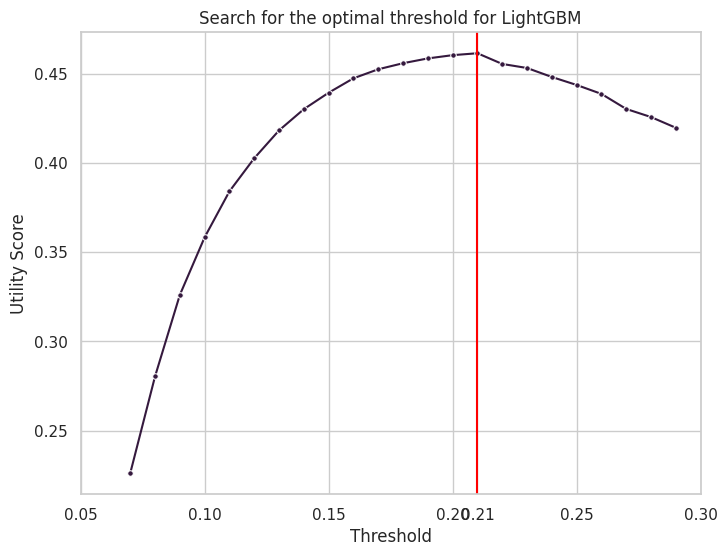

In [55]:
search_thr_graphic(hist_final, "LightGBM", best_t_final)

In [56]:
import joblib

joblib.dump(model, 'lgbm_sepsis_model.pkl')

['lgbm_sepsis_model.pkl']